## Imports

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from os import listdir
from os.path import isfile, join

#### LOADING DATA

In [18]:
path = "./trainings/"
history_dataframes = [pd.read_csv(join(path, f), index_col=0) for f in listdir(path) if isfile(join(path, f))]

## Comparison

**NUMBER OF EPOCHS**

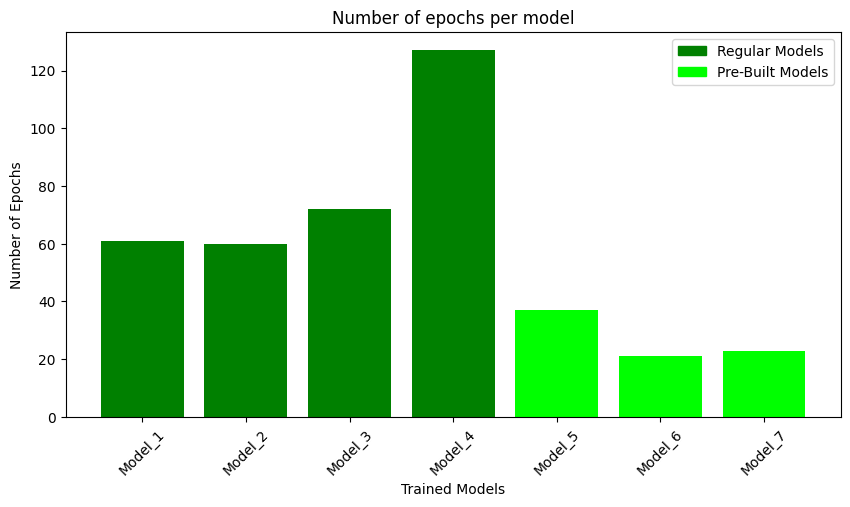

In [19]:
epochs = [len(df) for df in history_dataframes]
models = [f"Model_{i}" for i in range(1, len(epochs) + 1)]
colors = ['green'] * (len(models) - 3) + ['lime'] * 3  

# Bar plot
plt.figure(figsize=(10, 5))
plt.bar(models, epochs, color=colors)
plt.xlabel("Trained Models")
plt.ylabel("Number of Epochs")
plt.xticks(rotation=45)
plt.title("Number of epochs per model")

# Legend
legend_text = [
    mpatches.Patch(color='green', label='Regular Models'),
    mpatches.Patch(color='lime', label='Pre-Built Models')
]
plt.legend(handles=legend_text)

# Show
plt.show()

**Explanation**

As we can see in the image above, the models constructed by the students took nearly three times more epochs than the pre-built models (Inception, Xception, Residual). This could be caused due to the high model complexity in the second case.

In [20]:
student_models = epochs[:4]
pre_built_models = epochs[4:]

student_models_average_epochs = np.array(student_models).mean()
pre_built_models_average_epochs = np.array(pre_built_models).mean()

student_models_average_epochs, pre_built_models_average_epochs

(np.float64(80.0), np.float64(27.0))

The pre-built models present an average epoch number of **_27_**, while the models constructed by the students present an average epoch number of **_80_**.

**VALIDATION LOSS & ACCURACY**

ACCURACY

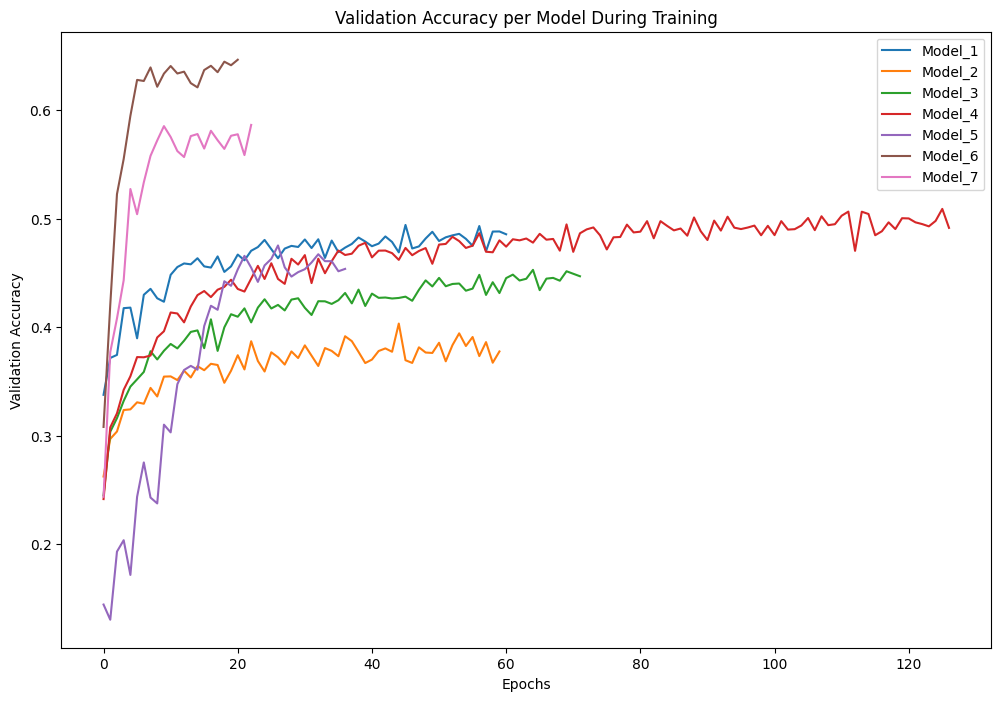

In [21]:
plt.figure(figsize=(12, 8))

for i, df in enumerate(history_dataframes):
    plt.plot(df.index, df['val_accuracy'], label=f"Model_{i+1}")

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy per Model During Training")
plt.legend()
plt.show()

LOSS

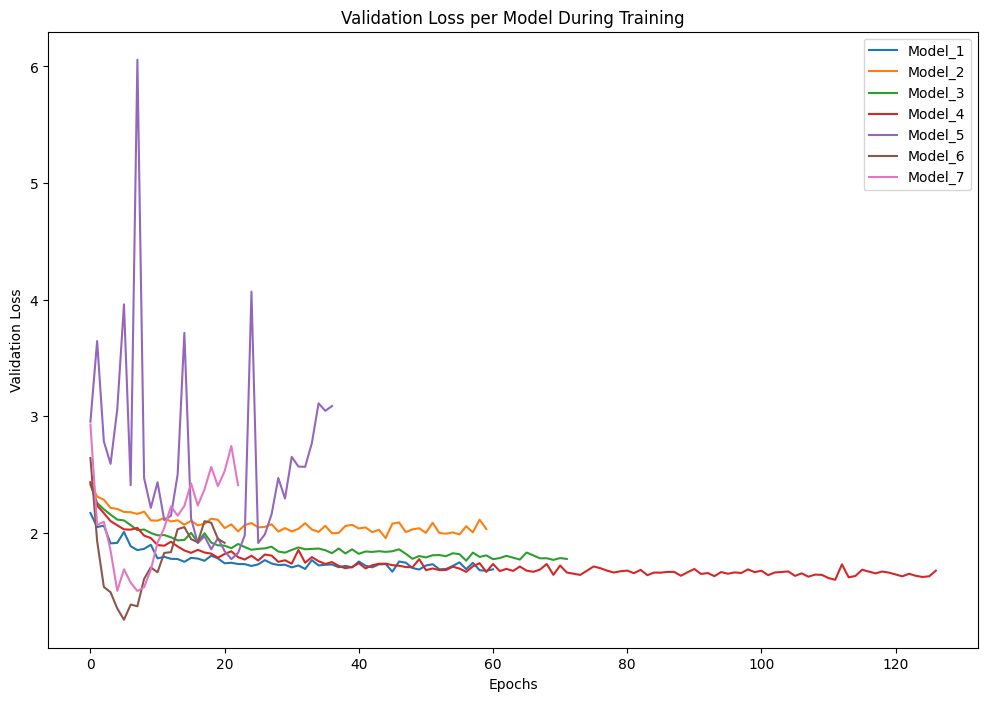

In [22]:
plt.figure(figsize=(12, 8))

for i, df in enumerate(history_dataframes):
    plt.plot(df.index, df['val_loss'], label=f"Model_{i+1}")

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss per Model During Training")
plt.legend()
plt.show()

**Explanation**

By looking at the graph above we can extract a series of conclusions, first eye we can observe how the best models in terms of validation accuracy during training are models number **6** and **7**. This makes sense, as these are the models with the most complex architectures. Something to take into consideration is that model number **5**, despite having one of the most complex architectures, has a worse performance compared to the rest of the prebuilt models.  

Also, by looking at the lines in the middle, we can see how most of the models made by the students have an accuracy around 50%, which is clearly better than randomly guessing (which in the case of a dataset with 20 labels would produce an accuracy of 5%), but is not near the 65% of validation accuracy achieved by the Xception model.

This is reinforced also by the Validation loss graph, where model number **5** presents the highest loss values during training, while the other complex architectures have the lowest loss values until early stopping is activated. 

---

**EVALUATION RESULTS**

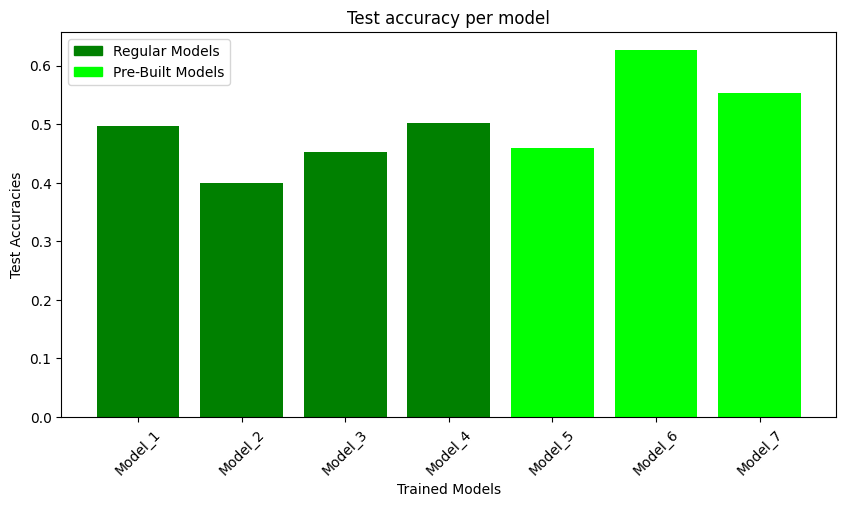

In [23]:
test_accuracies = {
    "Model_1": 0.497,
    "Model_2": 0.400,
    "Model_3": 0.453,
    "Model_4": 0.502,
    "Model_5": 0.459,
    "Model_6": 0.626,
    "Model_7": 0.553,
}
colors = ['green'] * (len(models) - 3) + ['lime'] * 3  

# Bar plot
plt.figure(figsize=(10, 5))
plt.bar(test_accuracies.keys(), test_accuracies.values(), color=colors)
plt.xlabel("Trained Models")
plt.ylabel("Test Accuracies")
plt.xticks(rotation=45)
plt.title("Test accuracy per model")

# Legend
legend_text = [
    mpatches.Patch(color='green', label='Regular Models'),
    mpatches.Patch(color='lime', label='Pre-Built Models')
]
plt.legend(handles=legend_text)

# Show
plt.show()

Finally, we can compare each model's results during the testing phase.  

In this case we can see a clear difference between the prebuilt models and the models made by the students. Where the former show a better performance in terms of accuracy (reaching values over 60%) while the latter reach and accuracy (in the best cases) of 50%.

Something surprising to take into account is that model number **5**, despite its complex architecture has a lower accuracy than some of the models constructed by the students.